# Wasserstein GANs (WGAN)

Wasserstein GANs introduce the following changes to vanilla GANs:

- Critic: The Discriminator in GANs turns into a Critic in WGAN. The role of the critic is similar to the discriminator, but its output is not bound as in a GAN (the critic does not use a sigmoid activation at its output). It can also be seen as a score of how real an image is, but it is harder to interpret as there is no maximum or minimum value.

- Error function: WGANs use the Wasserstein distance to measure the difference between the distributions of the real and fake data.

    - **Critic (Discriminator) Loss:**
        $$ L_{\text{critic}} = -\mathbb{E}_{x \sim p_{\text{real}}}[D(x)] + \mathbb{E}_{z \sim p_z}[D(G(z))] $$


    - **Generator Loss:**
        $$ L_{\text{generator}} = -\mathbb{E}_{z \sim p_z}[D(G(z))] $$

- Gradient Penalty: the gradient penalty enforces the 1-Lipschitz constraint, which requires the gradient norm of the critic to not be larger than 1. The original WGAN paper used weight clipping to enforce this. In WGAN-GP, the gradient penalty encourages the gradient norm to be close to 1 by penalizing deviations from this value.

- Training cycle: In a WGAN, the critic is trained for $n$ iterations (typically 5 or more) for each update of the generator.

These modifications aim to increase the stability in training. WGANs and WGAN-GP have been shown to provide more stable and robust training compared to vanilla GANs, both in theory and in empirical studies. However, they do not guarantee perfect stability in all settings.

**Refs**

- Martin Arjovsky, Soumith Chintala, and Léon Bottou (2017) - [Wasserstein GAN](https://arxiv.org/abs/1701.07875)

- Ishaan Gulrajani, Faruk Ahmed, Martin Arjovsky, Vincent Dumoulin, Aaron Courville (2017) - [Improved Training of Wasserstein GANs](https://proceedings.neurips.cc/paper_files/paper/2017/file/892c3b1c6dccd52936e27cbd0ff683d6-Paper.pdf)


    





In [27]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

import torchinfo

import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.patches import Rectangle

import numpy as np
import time
from tqdm import tqdm

import os
import pathlib
from PIL import Image
import skimage

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [28]:
def show_images(rows, cols, images):

    width= 2 * rows
    height= 2 * cols

    f, axes= plt.subplots(rows,cols,figsize=(height,width))
    fig=plt.figure()

    for a in range(rows*cols):

        axes.ravel()[a].imshow(np.clip(np.transpose(images[a].numpy(),(1,2,0))*0.5 + 0.5,0,1), cmap=plt.cm.gray)
        axes.ravel()[a].axis('off')
    fig.tight_layout()    
    plt.show()  

## Configuration

In [29]:
LATENT_SPACE_DIM = 16
BATCH_SIZE = 32

EPOCHS = 30

In [30]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(mean=[0.5], std=[0.5])]) 



train_set = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE,
                                          shuffle=True)

test_set = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE,
                                         shuffle=False)

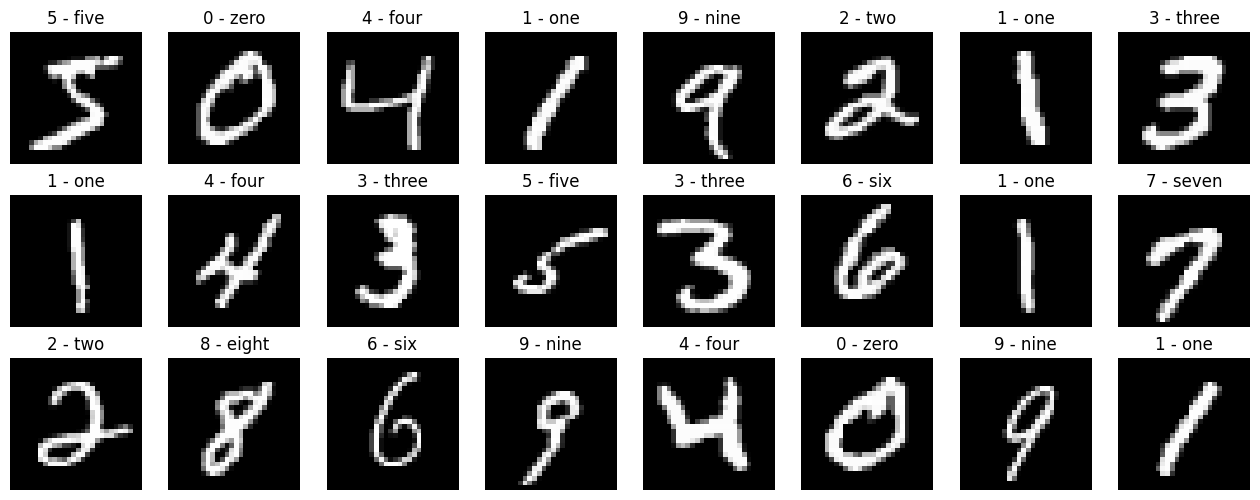

<Figure size 640x480 with 0 Axes>

In [31]:
images, targets = next(iter(train_loader))

# these are the transformed images
vcpi_util.show_transformed_images(3,8, train_set, train_set.classes) 

## Generator        

The WGAN generator is similar to a GAN generator

In [32]:
class Generator(nn.Module):

    def __init__(self, latent_dim = 16):
        super().__init__()

        self.model = nn.Sequential(
            # Input: (batch_size, latent_dim, 1, 1)
            nn.ConvTranspose2d(latent_dim, 128, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        # z shape: (batch_size, latent_dim)
        z = z.view(z.size(0), z.size(1), 1, 1)
        img = self.model(z)
        return img  # shape: (batch_size, 1, 28, 28)

In [33]:
G = Generator(LATENT_SPACE_DIM)
G.to(device)

torchinfo.summary(G, input_size = (BATCH_SIZE, LATENT_SPACE_DIM,1,1),
                                     col_names=["kernel_size", "input_size", "output_size", "num_params", "mult_adds"])

Layer (type:depth-idx)                   Kernel Shape              Input Shape               Output Shape              Param #                   Mult-Adds
Generator                                --                        [32, 16, 1, 1]            [32, 1, 28, 28]           --                        --
├─Sequential: 1-1                        --                        [32, 16, 1, 1]            [32, 1, 28, 28]           --                        --
│    └─ConvTranspose2d: 2-1              [7, 7]                    [32, 16, 1, 1]            [32, 128, 7, 7]           100,352                   157,351,936
│    └─BatchNorm2d: 2-2                  --                        [32, 128, 7, 7]           [32, 128, 7, 7]           256                       8,192
│    └─ReLU: 2-3                         --                        [32, 128, 7, 7]           [32, 128, 7, 7]           --                        --
│    └─ConvTranspose2d: 2-4              [4, 4]                    [32, 128, 7, 7]           

torch.Size([32, 1, 28, 28])


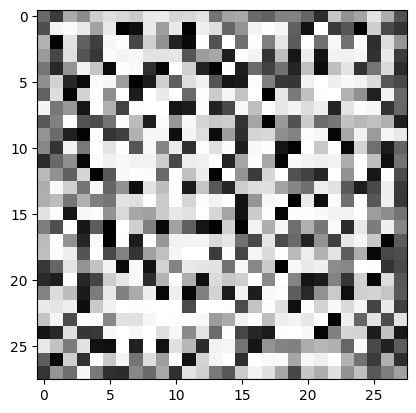

In [34]:
noise = torch.randn(BATCH_SIZE, LATENT_SPACE_DIM, 1, 1, device=device)

out = G(noise)
print(out.shape)

plt.imshow(np.transpose(out[0].detach().cpu().numpy() * 0.5 + 0.5, (1,2,0)), cmap='gray')

## Critic

The critic replaces the Discriminator in a GAN, the main difference being that, while the later has a sigmiod activation function for the output, the Critic produces an unbounded output.

In [35]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # Input: (batch_size, 1, 28, 28)
            nn.Conv2d(1, 64, 4, 2, 1, bias=True),   # No batchnorm in first layer
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1)
        )

    def forward(self, x):
        return self.model(x)

In [36]:
C = Critic()
C.to(device)

torchinfo.summary(C, input_size = (BATCH_SIZE, 1,28,28),
                                     col_names=["kernel_size", "input_size", "output_size", "num_params", "mult_adds"])

Layer (type:depth-idx)                   Kernel Shape              Input Shape               Output Shape              Param #                   Mult-Adds
Critic                                   --                        [32, 1, 28, 28]           [32, 1]                   --                        --
├─Sequential: 1-1                        --                        [32, 1, 28, 28]           [32, 1]                   --                        --
│    └─Conv2d: 2-1                       [4, 4]                    [32, 1, 28, 28]           [32, 64, 14, 14]          1,088                     6,823,936
│    └─LeakyReLU: 2-2                    --                        [32, 64, 14, 14]          [32, 64, 14, 14]          --                        --
│    └─Conv2d: 2-3                       [4, 4]                    [32, 64, 14, 14]          [32, 128, 7, 7]           131,072                   205,520,896
│    └─LeakyReLU: 2-4                    --                        [32, 128, 7, 7]       

## Training 

Training is a two step procedure, as in a vanilla GAN. 

The main differences are:

- Critic is trained for $n$ iterations per batch
- The error function is now based on the Wasserstein distance
- A gradient penalty term to discourage gradients with norms different from 1.


In [37]:
def gradient_penalty(C, real, fake):
    alpha = torch.rand(real.size(0), 1, 1, 1, device=real.device)
    interpolates = alpha * real + (1 - alpha) * fake
    interpolates.requires_grad_(True)

    scores = C(interpolates)
    grad_outputs = torch.ones_like(scores)

    gradients = torch.autograd.grad(
        outputs=scores,
        inputs=interpolates,
        grad_outputs=grad_outputs,
        create_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.view(gradients.size(0), -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gp

In [38]:
from tqdm.notebook import tqdm
import os
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np


def train_wgan_gp(
    G,
    C,
    train_loader,
    optimG,
    optimC,
    device,
    latent_dim,
    epochs=30,
    critic_steps=5,
    lambda_gp=10.0,
    latent_vis=None,
    save_prefix=None,
):
    G.train()
    C.train()
    G.to(device)
    C.to(device)

    if latent_vis is None:
        latent_vis = torch.randn(64, latent_dim, device=device)

    history = {
        "C_loss": [],
        "G_loss": [],
        "wasserstein": [],
        "gp": [],
    }

    if save_prefix is not None:
        save_dir = os.path.dirname(save_prefix)
        if save_dir != "":
            os.makedirs(save_dir, exist_ok=True)

    for epoch in range(epochs):
        epoch_c_loss = 0.0
        epoch_g_loss = 0.0
        epoch_w_dist = 0.0
        epoch_gp = 0.0

        data_iter = iter(train_loader)

        #pbar = tqdm(
        #    range(len(train_loader)),
        #    desc=f"Epoch {epoch + 1:03d}/{epochs:03d}",
        #    leave=True,
        #)

        for step in range(len(train_loader)):
            critic_loss_running = 0.0
            wasserstein_running = 0.0
            gp_running = 0.0

            for _ in range(critic_steps):
                try:
                    digits, _ = next(data_iter)
                except StopIteration:
                    data_iter = iter(train_loader)
                    digits, _ = next(data_iter)

                digits = digits.to(device)
                bsz = digits.size(0)

                optimC.zero_grad()

                z = torch.randn(bsz, latent_dim, device=device)
                fake_images = G(z).detach()

                out_real = C(digits).view(-1)
                out_fake = C(fake_images).view(-1)

                gp = gradient_penalty(C, digits, fake_images)
                wasserstein = out_real.mean() - out_fake.mean()
                errC = -wasserstein + lambda_gp * gp

                errC.backward()
                optimC.step()

                critic_loss_running += errC.item()
                wasserstein_running += wasserstein.item()
                gp_running += gp.item()

            errC_avg = critic_loss_running / critic_steps
            wasserstein_avg = wasserstein_running / critic_steps
            gp_avg = gp_running / critic_steps

            optimG.zero_grad()

            z = torch.randn(bsz, latent_dim, device=device)
            fake_images = G(z)
            out_gen = C(fake_images).view(-1)
            errG = -out_gen.mean()

            errG.backward()
            optimG.step()

            epoch_c_loss += errC_avg
            epoch_g_loss += errG.item()
            epoch_w_dist += wasserstein_avg
            epoch_gp += gp_avg

            #pbar.set_postfix(
            #    C=f"{epoch_c_loss / (step + 1):.3f}",
            #    G=f"{epoch_g_loss / (step + 1):.3f}",
            #    W=f"{epoch_w_dist / (step + 1):.3f}",
            #    GP=f"{epoch_gp / (step + 1):.3f}",
            #    refresh=False,
            #)

        #pbar.close()

        epoch_c_loss /= len(train_loader)
        epoch_g_loss /= len(train_loader)
        epoch_w_dist /= len(train_loader)
        epoch_gp /= len(train_loader)

        history["C_loss"].append(epoch_c_loss)
        history["G_loss"].append(epoch_g_loss)
        history["wasserstein"].append(epoch_w_dist)
        history["gp"].append(epoch_gp)

        print(
            f"Epoch {epoch + 1:03d}/{epochs:03d} | "
            f"C_loss: {epoch_c_loss:.4f} | "
            f"G_loss: {epoch_g_loss:.4f} | "
            f"W: {epoch_w_dist:.4f} | "
            f"GP: {epoch_gp:.4f}"
        )

        if (epoch % 5 == 0) or (epoch == epochs - 1):
            G.eval()
            with torch.no_grad():
                fake_vis = G(latent_vis[:64]).detach().cpu()
                grid = torchvision.utils.make_grid(fake_vis, nrow=8, padding=2, normalize=True)
                plt.figure(figsize=(8, 8))
                plt.imshow(np.transpose(grid, (1, 2, 0)), cmap="gray")
                plt.axis("off")
                plt.show()
            G.train()

        if save_prefix is not None:
            torch.save(
                {
                    "epoch": epoch,
                    "generator": G.state_dict(),
                    "optimG": optimG.state_dict(),
                    "critic": C.state_dict(),
                    "optimC": optimC.state_dict(),
                    "history": history,
                },
                f"{save_prefix}_{latent_dim}_{epoch}.pt",
            )

    return history

Epoch 001/030 | C_loss: -3.9430 | G_loss: -5.5572 | W: 4.6714 | GP: 0.0728


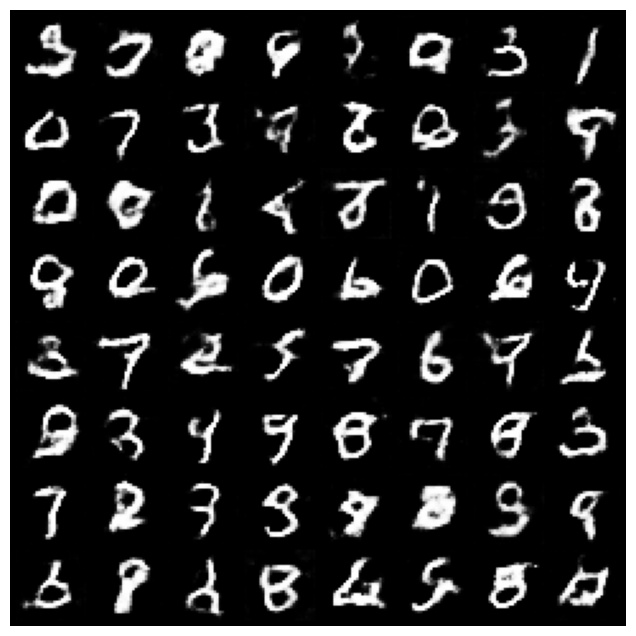

Epoch 002/030 | C_loss: -0.7342 | G_loss: -9.0982 | W: 0.7789 | GP: 0.0045
Epoch 003/030 | C_loss: -0.7135 | G_loss: -7.6641 | W: 0.7612 | GP: 0.0048
Epoch 004/030 | C_loss: -0.6877 | G_loss: -5.7233 | W: 0.7363 | GP: 0.0049
Epoch 005/030 | C_loss: -0.6709 | G_loss: -4.8226 | W: 0.7197 | GP: 0.0049
Epoch 006/030 | C_loss: -0.6613 | G_loss: -4.1873 | W: 0.7109 | GP: 0.0050


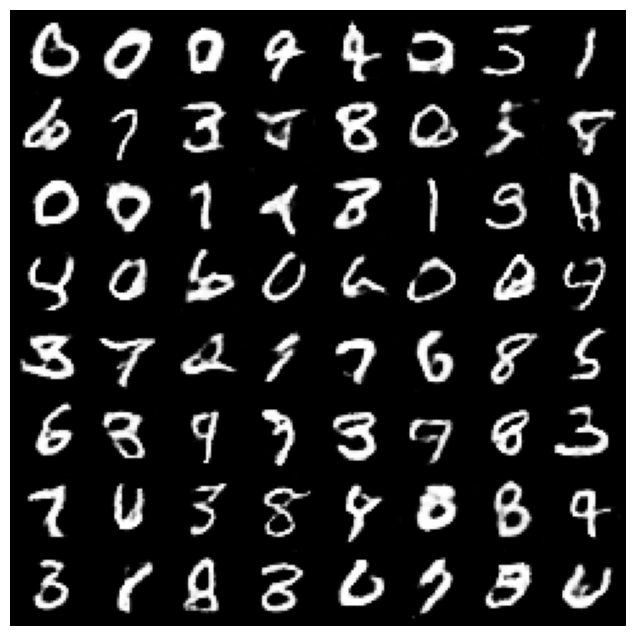

Epoch 007/030 | C_loss: -0.6527 | G_loss: -3.5113 | W: 0.7031 | GP: 0.0050
Epoch 008/030 | C_loss: -0.6532 | G_loss: -3.1093 | W: 0.7048 | GP: 0.0052
Epoch 009/030 | C_loss: -0.6590 | G_loss: -2.5792 | W: 0.7119 | GP: 0.0053
Epoch 010/030 | C_loss: -0.6597 | G_loss: -2.2625 | W: 0.7137 | GP: 0.0054
Epoch 011/030 | C_loss: -0.6640 | G_loss: -1.7420 | W: 0.7188 | GP: 0.0055


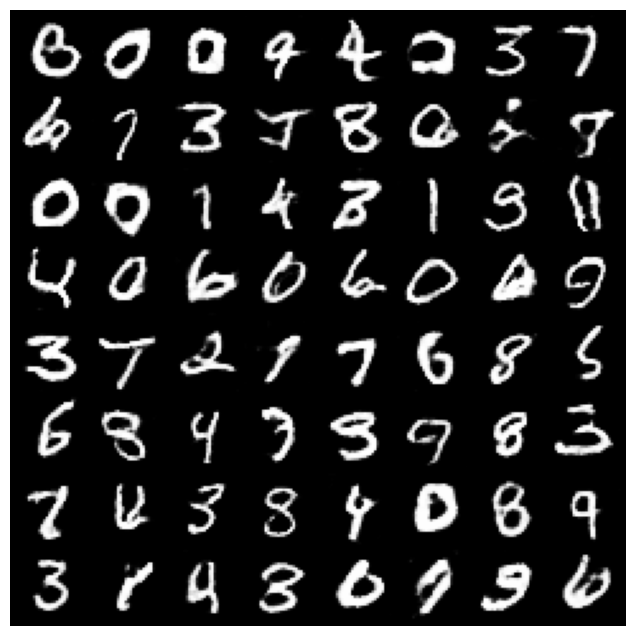

Epoch 012/030 | C_loss: -0.6638 | G_loss: -1.1794 | W: 0.7180 | GP: 0.0054
Epoch 013/030 | C_loss: -0.6664 | G_loss: -0.9404 | W: 0.7206 | GP: 0.0054
Epoch 014/030 | C_loss: -0.6681 | G_loss: -0.7194 | W: 0.7228 | GP: 0.0055
Epoch 015/030 | C_loss: -0.6669 | G_loss: -0.5528 | W: 0.7205 | GP: 0.0054
Epoch 016/030 | C_loss: -0.6745 | G_loss: -0.3486 | W: 0.7288 | GP: 0.0054


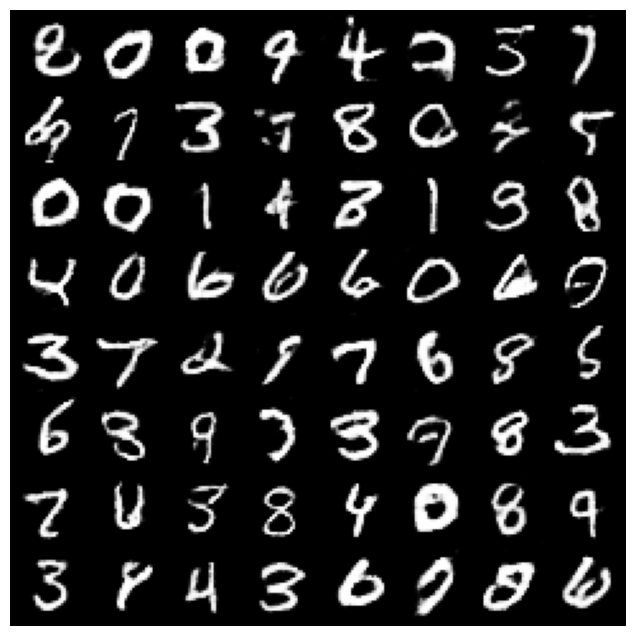

Epoch 017/030 | C_loss: -0.6795 | G_loss: -0.3395 | W: 0.7339 | GP: 0.0054
Epoch 018/030 | C_loss: -0.6849 | G_loss: 0.7308 | W: 0.7398 | GP: 0.0055
Epoch 019/030 | C_loss: -0.6873 | G_loss: 1.0043 | W: 0.7426 | GP: 0.0055
Epoch 020/030 | C_loss: -0.6894 | G_loss: 0.6217 | W: 0.7442 | GP: 0.0055
Epoch 021/030 | C_loss: -0.6859 | G_loss: 0.5954 | W: 0.7402 | GP: 0.0054


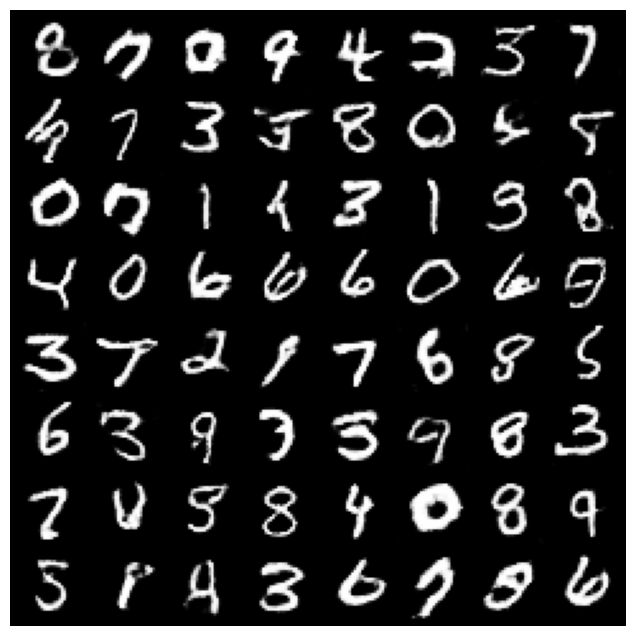

Epoch 022/030 | C_loss: -0.6860 | G_loss: 0.4577 | W: 0.7401 | GP: 0.0054
Epoch 023/030 | C_loss: -0.6873 | G_loss: 0.3297 | W: 0.7410 | GP: 0.0054
Epoch 024/030 | C_loss: -0.6813 | G_loss: 0.4240 | W: 0.7345 | GP: 0.0053
Epoch 025/030 | C_loss: -0.6832 | G_loss: 0.5318 | W: 0.7362 | GP: 0.0053
Epoch 026/030 | C_loss: -0.6796 | G_loss: 0.1853 | W: 0.7325 | GP: 0.0053


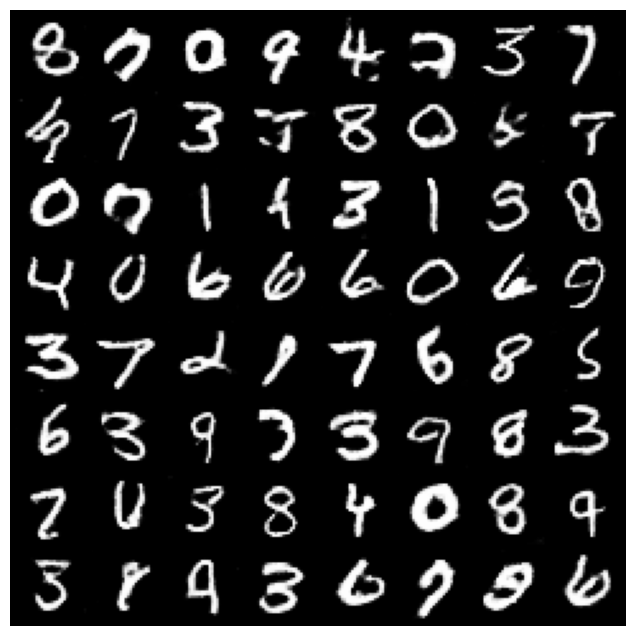

Epoch 027/030 | C_loss: -0.6782 | G_loss: 0.3553 | W: 0.7308 | GP: 0.0053
Epoch 028/030 | C_loss: -0.6779 | G_loss: 0.2381 | W: 0.7306 | GP: 0.0053
Epoch 029/030 | C_loss: -0.6786 | G_loss: 0.2014 | W: 0.7313 | GP: 0.0053
Epoch 030/030 | C_loss: -0.6747 | G_loss: 0.2780 | W: 0.7274 | GP: 0.0053


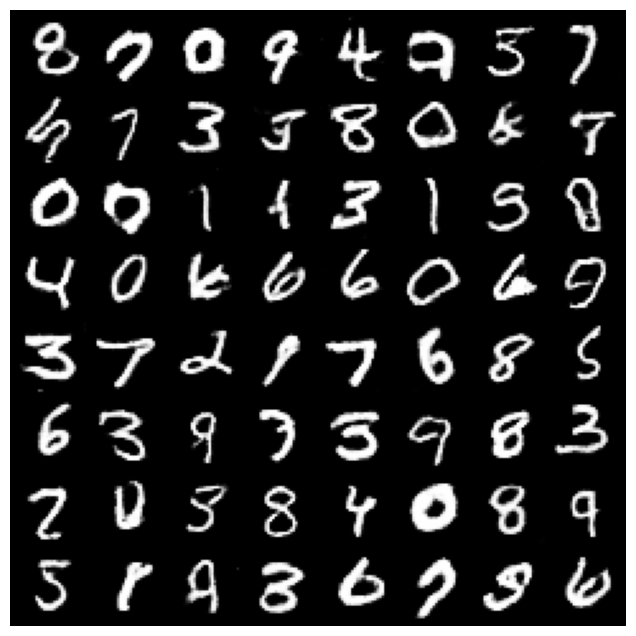

{'C_loss': [-3.9430427448368115,
  -0.7342333617097143,
  -0.7135236119836563,
  -0.6876536862017709,
  -0.6708573129479094,
  -0.6612538735135391,
  -0.6526727542861304,
  -0.6532250592768187,
  -0.658960685614744,
  -0.6597446100997933,
  -0.6640415827190881,
  -0.6637847218811495,
  -0.666449156492552,
  -0.6681477364071208,
  -0.6669031959935035,
  -0.6745444146601353,
  -0.6795229448771469,
  -0.6848740363113094,
  -0.6872607617660371,
  -0.6893830395650855,
  -0.6858742027421771,
  -0.6860174595614272,
  -0.6872951031327243,
  -0.6813382788040244,
  -0.683174757977723,
  -0.6796106286787983,
  -0.6781545788343754,
  -0.6778983901854366,
  -0.6785917794396479,
  -0.6747066294741616],
 'G_loss': [-5.557223223766685,
  -9.098160336561998,
  -7.664060816891988,
  -5.723339000638326,
  -4.822639510848125,
  -4.187332738180955,
  -3.511276823580265,
  -3.1092925602555277,
  -2.579249292795857,
  -2.2624982999950647,
  -1.7420309948682784,
  -1.1794128167768319,
  -0.9403747356792291,
 

In [39]:
EPOCHS = 30
iter_critic = 5
lambda_gp = 10

C = Critic()
C.to(device)
G = Generator(LATENT_SPACE_DIM)
G.to(device)

optim_C = torch.optim.Adam(C.parameters(), lr=1e-4, betas=(0.0, 0.9))
optim_G = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.0, 0.9))

train_wgan_gp(G,C,train_loader, optim_G, optim_C, device, LATENT_SPACE_DIM)